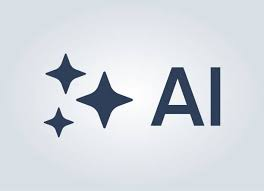

# WebScraping With AI

In [4]:
%%shell
# Update and install Google Chrome Stable
apt-get update
curl -sS -o - https://dl-ssl.google.com/linux/linux_signing_key.pub | apt-key add -
echo "deb [arch=amd64] http://dl.google.com/linux/chrome/deb/ stable main" >> /etc/apt/sources.list.d/google-chrome.list
apt-get update
apt-get install -y google-chrome-stable

# Install Selenium and Autoinstaller
pip install selenium chromedriver-autoinstaller

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,306 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,221 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.4 MB]
Get:14 

In [ ]:
#تست سلنیوم روی یوتیوب ...

from selenium import webdriver
from selenium.webdriver.chrome.options import Options
import chromedriver_autoinstaller
import time

try:
    print("Initializing Chrome Driver for YouTube test...")
    chromedriver_autoinstaller.install()

    chrome_options = Options()
    chrome_options.add_argument('--headless')
    chrome_options.add_argument('--no-sandbox')
    chrome_options.add_argument('--disable-dev-shm-usage')
    chrome_options.add_argument('--disable-gpu')
    chrome_options.page_load_strategy = 'eager'
    chrome_options.add_argument('user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36')
    chrome_options.binary_location = "/usr/bin/google-chrome"

    driver = webdriver.Chrome(options=chrome_options)
    driver.set_page_load_timeout(30)

    url = 'https://www.youtube.com'
    print(f"Attempting to access: {url}")
    driver.get(url)

    time.sleep(5)

    print(f"Current URL: {driver.current_url}")
    print(f"Page Title: {driver.title}")

    if "youtube" in driver.current_url.lower() or "YouTube" in driver.title:
        print("Success! YouTube is accessible.")
    else:
        print("Warning: Could not verify YouTube connection.")

except Exception as e:
    print(f"Error occurred: {str(e)}")
finally:
    if 'driver' in locals():
        driver.quit()
        print("Youtube Session Ended.")

Initializing Chrome Driver for YouTube test...
Attempting to access: https://www.youtube.com
Current URL: https://www.youtube.com/
Page Title: YouTube
Success! YouTube is accessible.
Youtube Session Ended.


In [ ]:
!pip install openai

# تست هوش مصنوعی

In [13]:
import os
from openai import OpenAI
from google.colab import userdata # Import userdata

# Retrieve API_KEY and WorkSpaceID from Colab secrets
api_key = "sk-ws-H.IEEXHL.cLJZ.MEYCIQCKIr3gsXlDwhISqgB8GphirLZEzLGqueEXm05SW9gKTgIhAOE2Cmahmo4aryj6IoLU5NEvcljNivhz74aVcXE2Up5v"
workspaceID = "ws-kaif0dqa9vetugh8"

# Add checks for missing secrets
if not api_key:
    print("Warning: API_KEY not found in Colab secrets. Please add it using the 🔑 icon.")
if not workspaceID:
    print("Warning: WorkSpaceID not found in Colab secrets. Please add it using the 🔑 icon.")

# Note: The base_url varies by region. The following example uses the base_url for the Singapore region.
# - Singapore: https://{WorkspaceId}.ap-southeast-1.maas.aliyuncs.com/compatible-mode/v1. Replace {WorkspaceId} with your workspace ID.
# - China (Beijing): https://{WorkspaceId}.cn-beijing.maas.aliyuncs.com/compatible-mode/v1
# - China (Hong Kong): https://{WorkspaceId}.cn-hongkong.maas.aliyuncs.com/compatible-mode/v1
# - Germany (Frankfurt): https://{WorkspaceId}.eu-central-1.maas.aliyuncs.com/compatible-mode/v1
# - US (Virginia): https://dashscope-us.aliyuncs.com/compatible-mode/v1

client = None # Initialize client to None
base_url_val = None

if workspaceID:
    # Fixed base_url string interpolation
    base_url_val = f"https://{workspaceID}.ap-southeast-1.maas.aliyuncs.com/compatible-mode/v1"
else:
    print("Base URL cannot be constructed without WorkSpaceID.")

if api_key and base_url_val:
    try:
        client = OpenAI(
            api_key=api_key,
            base_url=base_url_val
        )
        print("OpenAI client initialized.")
    except Exception as e:
        print(f"Error initializing OpenAI client: {e}")
else:
    print("OpenAI client not initialized due to missing API_KEY or WorkSpaceID. Please set them in Colab secrets.")

# Removed the test completion call as it is no longer just for testing API setup.

OpenAI client initialized.


### AI-Powered Web Scraping

This section implements functions for web scraping where an AI model helps identify elements on a webpage based on a natural language description. The `get_selector_from_ai` function queries the AI for a CSS selector, and `scrape_with_ai` uses this selector to interact with the webpage via Selenium.

In [21]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
import chromedriver_autoinstaller
import time
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys

In [17]:
# Helper function to get selector from AI
def get_selector_from_ai(client_obj, html_content, user_description):
    if client_obj is None:
        print("OpenAI client is not initialized. Cannot get selector from AI.")
        return None

    prompt = f"""
    You are an expert web scraper. Given the following HTML content and a user's request,
    identify the best CSS selector for the element the user is describing.
    If the user asks for a button, provide a selector that targets that button.
    If the user asks for text, provide a selector that targets the element containing that text.
    If multiple elements match the description, prioritize unique and specific selectors (e.g., IDs over classes, specific classes over generic tags).
    If no suitable element is found, return "NOT_FOUND".
    Return only the CSS selector or "NOT_FOUND". Do not add any other text.

    HTML Content:
    {html_content}

    User Request: "{user_description}"

    CSS Selector:
    """

    try:
        response = client_obj.chat.completions.create(
            model="qwen3.7-plus", # Use the appropriate model name
            messages=[
                {"role": "user", "content": prompt}
            ],
            temperature=0.0
        )
        selector = response.choices[0].message.content.strip()
        return selector if selector != "NOT_FOUND" else None
    except Exception as e:
        print(f"Error calling AI for selector: {e}")
        return None

In [25]:
# Main function to scrape and interact with AI assistance
def scrape_with_ai(url, user_description, text_to_input=None):
    print(f"Starting AI-assisted scraping for URL: {url} with description: '{user_description}'")

    driver = None
    try:
        chromedriver_autoinstaller.install()
        chrome_options = Options()
        chrome_options.add_argument('--headless')
        chrome_options.add_argument('--no-sandbox')
        chrome_options.add_argument('--disable-dev-shm-usage')
        chrome_options.add_argument('--disable-gpu')
        chrome_options.page_load_strategy = 'eager'
        chrome_options.add_argument('user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36')
        chrome_options.binary_location = "/usr/bin/google-chrome"

        driver = webdriver.Chrome(options=chrome_options)
        driver.set_page_load_timeout(30)

        print(f"Accessing: {url}")
        driver.get(url)
        time.sleep(5) # Give page some time to load completely, especially for dynamic content

        html_content = driver.page_source
        print("Page loaded. Sending HTML to AI to find element based on description...")

        # Pass the global client object to get_selector_from_ai
        # client is expected to be defined globally by cell SehrcEa8F9BW
        selector = get_selector_from_ai(client, html_content, user_description)

        if selector:
            print(f"AI identified selector: '{selector}'")
            try:
                element = driver.find_element(By.CSS_SELECTOR, selector)
                tag_name = element.tag_name.lower()

                if tag_name == 'button' or tag_name == 'a' or (tag_name == 'input' and element.get_attribute('type') == 'submit'):
                    print(f"Attempting to click on element with tag '{tag_name}' and text '{element.text}'...")
                    try:
                        element.click()
                    except Exception as click_error:
                        print(f"Direct click failed, trying JavaScript click: {click_error}")
                        driver.execute_script("arguments[0].click();", element)

                    time.sleep(3) # Wait for navigation/action
                    print(f"Action performed. New URL: {driver.current_url}")
                    return {"status": "clicked", "new_url": driver.current_url}
                elif tag_name in ['input', 'textarea']:
                    if text_to_input is not None:
                        print(f"Typing '{text_to_input}' into element with tag '{tag_name}'...")
                        element.send_keys(text_to_input)
                        element.send_keys(Keys.RETURN) # Simulate pressing Enter after typing
                        time.sleep(3) # Wait for search results or form submission
                        print(f"Text typed and submitted. Current URL: {driver.current_url}")
                        return {"status": "typed_and_submitted", "text_typed": text_to_input, "new_url": driver.current_url}
                    else:
                        value = element.get_attribute('value')
                        print(f"Extracted value from input/textarea: {value}")
                        return {"status": "extracted", "value": value}
                else:
                    text_content = element.text
                    print(f"Extracted text content: {text_content}")
                    return {"status": "extracted", "text": text_content}
            except Exception as e:
                print(f"Error interacting with element using selector '{selector}': {e}")
                return {"status": "error", "message": f"Could not interact with element: {e}"}
        else:
            print("AI could not find a suitable selector based on the description.")
            return {"status": "not_found"}

    except Exception as e:
        print(f"An error occurred during scraping: {e}")
        return {"status": "error", "message": str(e)}
    finally:
        if driver:
            driver.quit()
            print("Scraping session ended.")

### Example Usage

To use the AI-assisted web scraping, provide a URL and a description of the element you want to interact with. The AI will attempt to find the correct selector, and Selenium will then perform the action (click or extract text).

**Note**: Replace `"https://www.example.com"` and `"the main contact button"` with your desired URL and a clear description.

In [27]:
# Example of AI-assisted scraping
# Replace with your target URL and element description
example_url = "https://github.com"
example_description = "بخش ثبت نام " # Describe the input field more directly
text_to_type = "ایران"

result = scrape_with_ai(example_url, example_description, text_to_input=text_to_type)
print("\n--- Scraping Result ---")
print(result)

Starting AI-assisted scraping for URL: https://github.com with description: 'توضیحات رو بردار'
Accessing: https://github.com
Page loaded. Sending HTML to AI to find element based on description...
AI identified selector: '.lp-SectionIntro-description, .lp-CustomerStories-description, .lp-Cta-description'
Extracted text content: From your first line of code to final deployment, GitHub provides AI and automation tools to help you build and ship better software faster.
Scraping session ended.

--- Scraping Result ---
{'status': 'extracted', 'text': 'From your first line of code to final deployment, GitHub provides AI and automation tools to help you build and ship better software faster.'}
